#### Ashbah Faisal
#### af08271
#### HOMEWORK ASSIGNMENT 4:SQL

In [81]:
import pandas as pd
import numpy as np
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas.io.sql as psql
import sqlalchemy

In [89]:
conn = psycopg2.connect(
    host="localhost",
    database="postgres",
    user="postgres",
    password="1234",
    port="5433"
)


In [91]:
df2 = psql.read_sql('SELECT * FROM countries',conn)
df3 = psql.read_sql('SELECT * FROM cities',conn)

C:\Users\cw\AppData\Local\Temp\ipykernel_5316\317325132.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = psql.read_sql('SELECT * FROM countries',conn)
C:\Users\cw\AppData\Local\Temp\ipykernel_5316\317325132.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3 = psql.read_sql('SELECT * FROM cities',conn)


In [25]:
# df2.head()
# df3.head()

,city_id,city_name,city_population,capital,fact_id
0,1,Oranjestad,37000,1,216
1,2,Saint John'S,27000,1,6
2,3,Abu Dhabi,942000,1,184
3,4,Dubai,1978000,0,184
4,5,Sharjah,983000,0,184


### Univariate bar graph to count the number of countries in each region

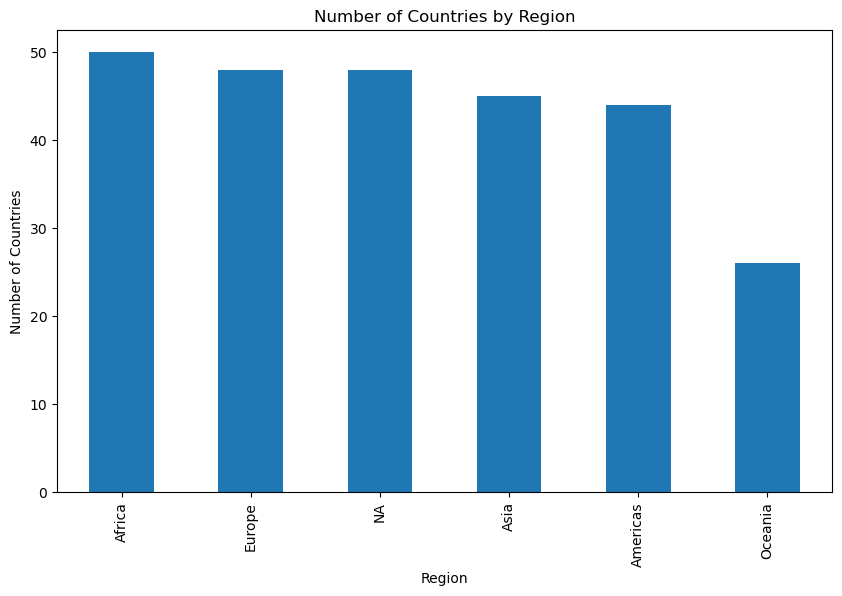

In [35]:
# Count the number of countries in each region
region_counts = df2['country_region'].value_counts()

# Plotting the count of countries by region
region_counts.plot(kind='bar', title='Number of Countries by Region', figsize=(10, 6))

plt.xlabel('Region')
plt.ylabel('Number of Countries')
plt.show()



### Conclusion
The bar chart shows the number of countries in each region, with regions like Africa having the highest count while Oceania has the lowest count. Using the country_region column, where the count of countries was calculated and displayed on the y-axis for each region on the x-axis.

### Bivariate to do Country area in land vs Country area in Water

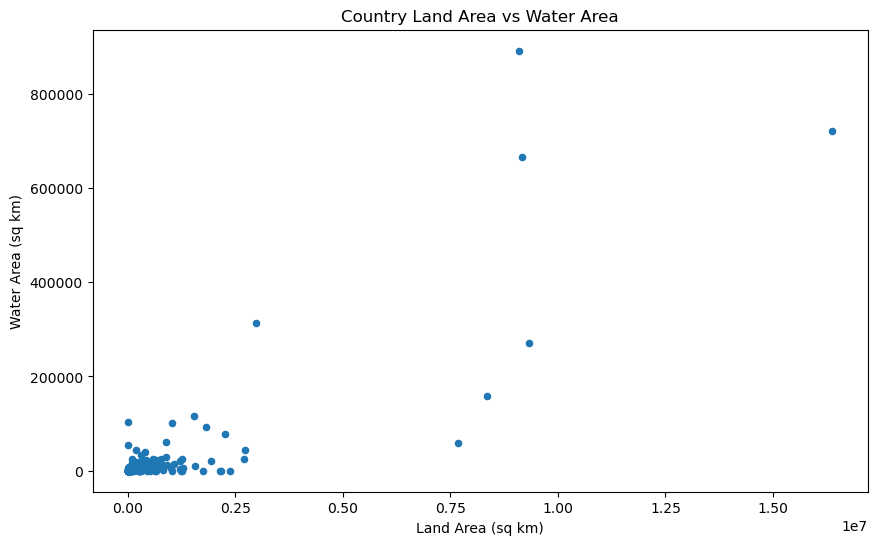

In [46]:
# Scatter plot comparing country_area_land and country_area_water
df2.plot(kind='scatter', x='country_area_land', y='country_area_water', title='Country Land Area vs Water Area', figsize=(10, 6))

plt.xlabel('Land Area (sq km)')
plt.ylabel('Water Area (sq km)')
plt.show()


### Conclusion
This bivariate graph plots the land area (x-axis) against the water area (y-axis) of different countries.
most countries cluster at low values of both land and water areas, while a few outliers have significantly larger land or water areas. The country with the largest land area shows a smaller water area compared to the country with the highest water area.

### Bivariate to do city name vs city population

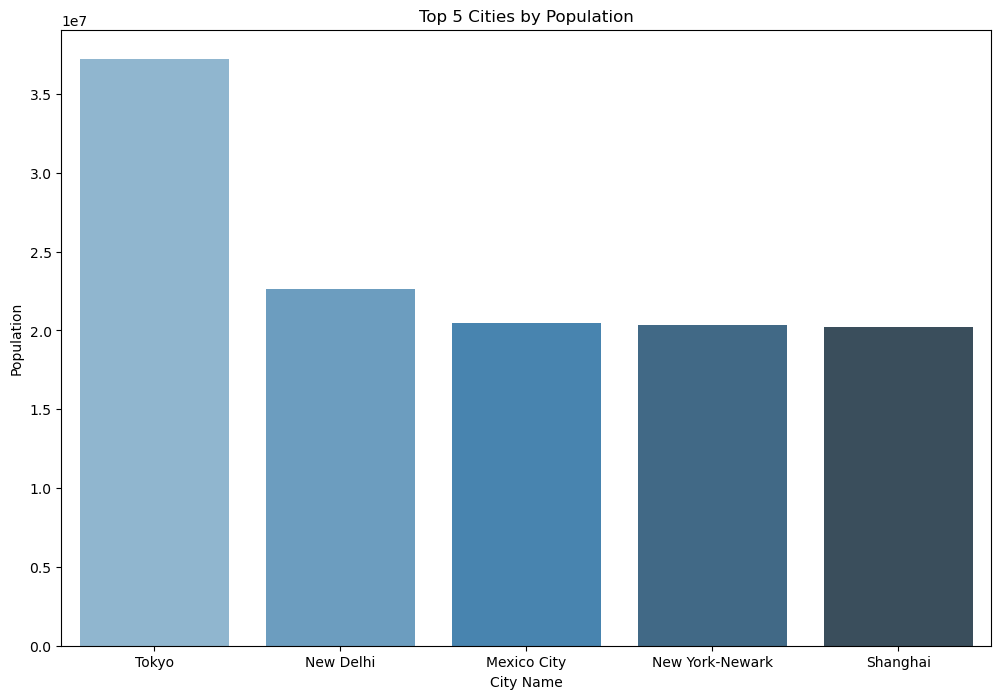

In [78]:
top_cities = df3.sort_values(by='city_population', ascending=False).head(5)

# Step 2: Create the horizontal bar plot using Seaborn
plt.figure(figsize=(12, 8))
sns.barplot(data=top_cities, x='city_name', y='city_population',hue='city_name', palette='Blues_d')

plt.title('Top 5 Cities by Population')
plt.xlabel('City Name')
plt.ylabel('Population')
plt.show()

### Conclusion
The bar graph shows the top 5 cities by population. Tokyo has the highest population while shanghai has the lowest population among the top 5 . x-axis displays the countries while the y-axis shows population.

### Correalaion graph to draw multiple comparisons 

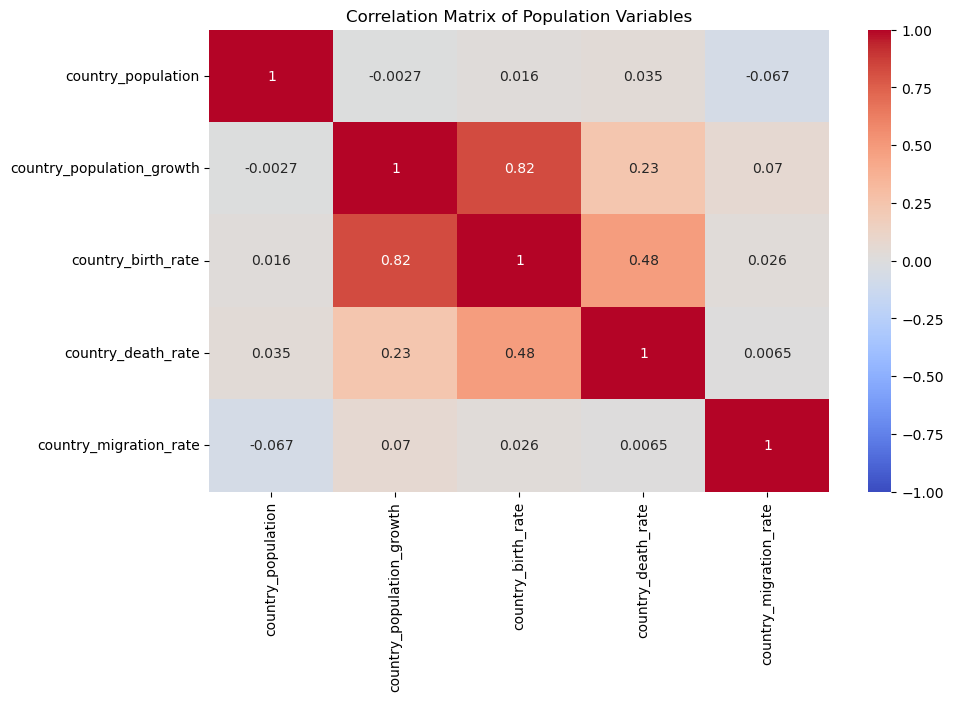

In [48]:

# Calculate the correlation matrix
correlation_matrix = df2[['country_population', 'country_population_growth', 'country_birth_rate', 'country_death_rate', 'country_migration_rate']].corr()

# Plotting the correlation matrix using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix of Population Variables')
plt.show()


### Conclusion
The map compares the country population,birt rate death rate and migration rate all these are factors which affect a countries population.
Country Population shows weak or no correlation with the other variables.
Population Growth is strongly positively correlated with Birth Rate (0.82), indicating countries with higher birth rates tend to have higher population growth hence they have a strong correalation
Birth Rate also has a moderate positive correlation with Death Rate (0.48).
Migration Rate shows very weak or no correlation with the other variables.